# Exam timetabling
Schedule each exam into a period and into a room. Multiple exams can share the same room during the same period.


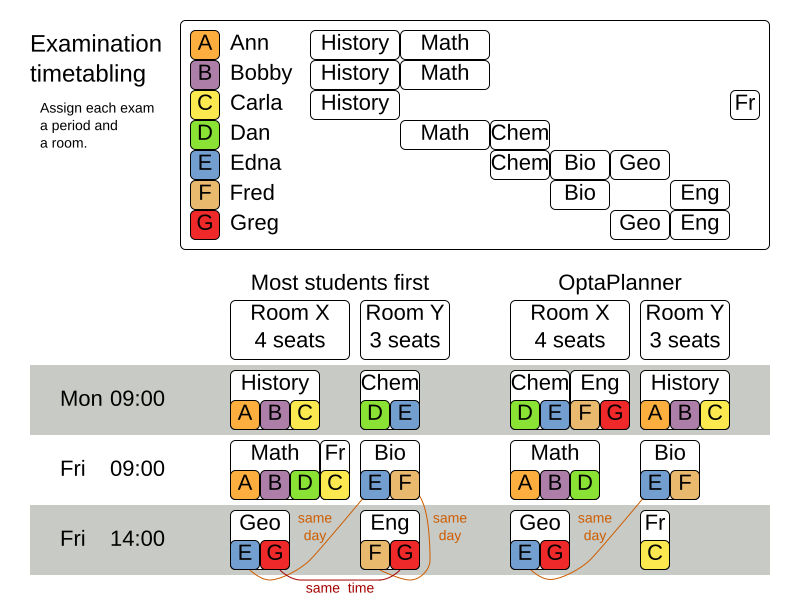

In [20]:
!pip install gurobipy
import gurobipy as gp
from gurobipy import GRB, quicksum
from datetime import datetime

#Hard constraints:

*   Exam conflict: two exams that share students must not occur in the same period.
*   Room capacity: A room’s seating capacity must suffice at all times.

*   Period duration: A period’s duration must suffice for all of its exams.
*   Period related hard constraints (specified per dataset):


1.   Coincidence: two specified exams must use the same period (but possibly another room).
2.   Exclusion: two specified exams must not use the same period.
3. After: A specified exam must occur in a period after another specified exam’s period.

* Room related hard constraints (specified per dataset):

1. Exclusive: one specified exam should not have to share its room with any other exam.

# Soft constraints (each of which has a parametrized penalty):

* The same student should not have two exams in a row.

* The same student should not have two exams on the same day.

* Period spread: two exams that share students should be a number of periods apart.

* Mixed durations: two exams that share a room should not have different durations.

* Front load: Large exams should be scheduled earlier in the schedule.

* Period penalty (specified per dataset): Some periods have a penalty when used.

* Room penalty (specified per dataset): Some rooms have a penalty when used.


It uses large test data sets of real-life universities.

The problem is defined by the International Timetabling Competition 2007 track 1. Geoffrey De Smet finished 4th in that competition with a very early version of OptaPlanner. Many improvements have been made since then


#Problem Size

exam_comp_set1 has  7883 students,  607 exams, 54 periods,  7 rooms,  12 period constraints and  0 room constraints with a search space of 10^1564.

exam_comp_set2 has 12484 students,  870 exams, 40 periods, 49 rooms,  12 period constraints and  2 room constraints with a search space of 10^2864.

exam_comp_set3 has 16365 students,  934 exams, 36 periods, 48 rooms, 168 period constraints and 15 room constraints with a search space of 10^3023.

exam_comp_set4 has  4421 students,  273 exams, 21 periods,  1 rooms,  40 period constraints and  0 room constraints with a search space of  10^360.

exam_comp_set5 has  8719 students, 1018 exams, 42 periods,  3 rooms,  27 period constraints and  0 room constraints with a search space of 10^2138.

exam_comp_set6 has  7909 students,  242 exams, 16 periods,  8 rooms,  22 period constraints and  0 room constraints with a search space of  10^509.

exam_comp_set7 has 13795 students, 1096 exams, 80 periods, 15 rooms,  28 period constraints and  0 room constraints with a search space of 10^3374.

exam_comp_set8 has  7718 students,  598 exams, 80 periods,  8 rooms,  20 period constraints and  1 room constraints with a search space of 10^1678.

#Parse exam data

In [2]:
from google.colab import files

uploaded = files.upload()  # Upload 'exam_comp_set1.exam' file


Saving exam_comp_set1 - Copy.exam to exam_comp_set1 - Copy.exam


In [9]:
file_path = list(uploaded.keys())[0]
with open(file_path, 'r') as file:
    content = file.read()
print(content[:])

[Exams:607]
195, 2829, 2864, 2882, 4466, 4571, 4878, 4913, 5077, 5082, 5083, 5113, 5127, 5129, 5131, 5134, 5160, 5174, 5175, 5176, 5177, 5192, 5194, 5326, 5362, 5367, 5368, 5369, 5376, 5380, 5381, 5382, 5383, 5388, 5389, 5393, 5396, 5401, 5402, 5403, 5404, 5405, 5409, 5410, 5411, 5418, 5457, 5525, 5529, 5576, 5578, 5579, 5581, 5594, 5600, 5603, 5604, 5605, 5606, 5607, 5618, 5628, 5632, 5639, 5642, 5645, 5668, 5686, 5693, 5695, 5702, 5703, 5704, 5708, 5714, 5716, 5718, 5723, 5727, 5730, 5731, 5732, 5733, 5734, 5735, 5797, 5798, 5799, 5800, 5801, 5855, 5856, 5858, 5860, 5861, 5862, 5864, 5877, 5879, 5880, 5945, 5947, 5949, 5950, 5951, 5956, 5961, 5968, 6009, 6011, 6063, 6149, 6156, 6165, 6168, 6169, 6170, 6171, 6179, 6220, 6221, 6226, 6230, 6231, 6232, 6233, 6234, 6235, 6236, 6237, 6238, 6239, 6242, 6246, 6250, 6261, 6263, 6264, 6265, 6266, 6267, 6269, 6272, 6274, 6275, 6279, 6282, 6285, 6287, 6288, 6290, 6390, 6411, 6413, 6418, 6419, 6459, 6470, 6600, 6681, 6684, 6687, 6688, 6689, 6783,

In [4]:
exam_students = {}
all_students = set()

with open("exam_comp_set1 - Copy.exam", "r") as f:
    lines = f.readlines()

exam_index = 0
for line in lines[1:]:  # Skip first line if it has metadata
    line = line.strip()
    if not line or line.startswith('['):  # Skip empty or comment lines
        continue
    student_ids = [int(sid.strip(',')) for sid in line.split()]
    exam_students[exam_index] = student_ids
    all_students.update(student_ids)
    exam_index += 1

E = list(exam_students.keys())  # Exams
S = list(all_students)          # Students


#Define Periods (from user input)

In [12]:
# ==== Raw Period Data ====
raw_data = """
15:04:2005, 09:30:00, 210, 0
15:04:2005, 14:00:00, 210, 0
18:04:2005, 09:30:00, 210, 0
15:04:2005, 09:30:00, 210, 0
15:04:2005, 14:00:00, 210, 0
18:04:2005, 09:30:00, 210, 0
18:04:2005, 14:00:00, 210, 70
19:04:2005, 09:30:00, 210, 50
19:04:2005, 14:00:00, 210, 0
20:04:2005, 09:30:00, 210, 0
20:04:2005, 14:00:00, 210, 0
21:04:2005, 09:30:00, 210, 0
21:04:2005, 14:00:00, 210, 0
22:04:2005, 09:30:00, 210, 0
22:04:2005, 14:00:00, 210, 0
25:04:2005, 09:30:00, 210, 0
25:04:2005, 14:00:00, 210, 0
26:04:2005, 09:30:00, 210, 0
26:04:2005, 14:00:00, 210, 0
27:04:2005, 09:30:00, 210, 0
27:04:2005, 14:00:00, 210, 0
28:04:2005, 09:30:00, 210, 0
28:04:2005, 14:00:00, 210, 50
29:04:2005, 09:30:00, 210, 0
29:04:2005, 14:00:00, 210, 0
02:05:2005, 14:00:00, 210, 0
03:05:2005, 09:30:00, 210, 0
03:05:2005, 14:00:00, 210, 0
04:05:2005, 09:30:00, 210, 0
04:05:2005, 14:00:00, 210, 0
05:05:2005, 09:30:00, 210, 0
05:05:2005, 14:00:00, 210, 0
06:05:2005, 09:30:00, 210, 0
06:05:2005, 14:00:00, 210, 0
09:05:2005, 09:30:00, 210, 0
09:05:2005, 14:00:00, 210, 0
10:05:2005, 09:30:00, 210, 0
10:05:2005, 14:00:00, 210, 0
11:05:2005, 09:30:00, 210, 0
11:05:2005, 14:00:00, 210, 0
12:05:2005, 09:30:00, 210, 0
12:05:2005, 14:00:00, 210, 0
13:05:2005, 09:30:00, 210, 0
13:05:2005, 14:00:00, 210, 0
14:05:2005, 09:30:00, 210, 0
16:05:2005, 09:30:00, 210, 0
16:05:2005, 14:00:00, 210, 0
17:05:2005, 09:30:00, 210, 0
17:05:2005, 14:00:00, 210, 0
18:05:2005, 09:30:00, 210, 0
18:05:2005, 14:00:00, 210, 50
19:05:2005, 09:30:00, 210, 0
19:05:2005, 14:00:00, 210, 0
20:05:2005, 09:30:00, 210, 0
20:05:2005, 14:00:00, 210, 0
21:05:2005, 09:30:00, 210, 0
23:05:2005, 09:30:00, 210, 0
""".strip().splitlines()

In [13]:
from datetime import datetime
from collections import defaultdict

P = set()  # Period IDs
period_info = {}  # period_id -> (date, time, duration, penalty)
Lp = {}  # period_id -> duration
undesirable_periods = set()  # Periods with soft constraint penalties
Psame_day = defaultdict(list)  # date -> list of period_ids

for idx, line in enumerate(raw_data):
    date_str, time_str, duration_str, penalty_str = [x.strip() for x in line.split(',')]
    period_id = idx
    date_obj = datetime.strptime(date_str, "%d:%m:%Y").date()
    duration = int(duration_str)
    penalty = int(penalty_str)

    # Add to data structures
    P.add(period_id)
    period_info[period_id] = (date_obj, time_str, duration, penalty)
    Lp[period_id] = duration
    Psame_day[date_obj].append(period_id)

    if penalty > 0:
        undesirable_periods.add(period_id)

# ==== Output ====
print("Total periods:", len(P))
print("Sample period:", period_info[0])
print("Undesirable periods:", sorted(undesirable_periods))


Total periods: 57
Sample period: (datetime.date(2005, 4, 15), '09:30:00', 210, 0)
Undesirable periods: [6, 7, 22, 50]


#Room Data


In [14]:
# ==== Raw Room Data ====
raw_room_data = """
260, 0
100, 0
129, 50
60, 50
77, 0
65, 0
111, 0
""".strip().splitlines()

# ==== Parse Room Info ====
R = set()
Cr = {}                 # room_id -> capacity
undesirable_rooms = set()

for idx, line in enumerate(raw_room_data):
    capacity_str, penalty_str = [x.strip() for x in line.split(',')]
    capacity = int(capacity_str)
    penalty = int(penalty_str)

    R.add(idx)
    Cr[idx] = capacity

    if penalty > 0:
        undesirable_rooms.add(idx)

# ==== Example Output ====
print("Rooms:", R)
print("Capacities:", Cr)
print("Undesirable rooms:", undesirable_rooms)



Rooms: {0, 1, 2, 3, 4, 5, 6}
Capacities: {0: 260, 1: 100, 2: 129, 3: 60, 4: 77, 5: 65, 6: 111}
Undesirable rooms: {2, 3}


#PeriodHardConstraints

In [15]:
raw_period_constraints = """
11, AFTER, 10
26, AFTER, 25
98, AFTER, 97
165, AFTER, 164
418, AFTER, 417
425, EXAM_COINCIDENCE, 426
100, EXCLUSION, 120
495, AFTER, 494
496, AFTER, 495
529, EXAM_COINCIDENCE, 528
555, AFTER, 554
601, AFTER, 600
""".strip().splitlines()

# Output: Constraint groups
after_constraints = []          # List of tuples (e1, e2) => e1 after e2
coincidence_constraints = []    # List of tuples (e1, e2) => e1 and e2 same period
exclusion_constraints = []      # List of tuples (e1, e2) => e1 and e2 not same period

# Parse each line
for line in raw_period_constraints:
    e1, ctype, e2 = [x.strip() for x in line.split(',')]
    e1, e2 = int(e1), int(e2)

    if ctype == "AFTER":
        after_constraints.append((e1, e2))
    elif ctype == "EXAM_COINCIDENCE":
        coincidence_constraints.append((e1, e2))
    elif ctype == "EXCLUSION":
        exclusion_constraints.append((e1, e2))
    else:
        print("Unknown constraint type:", ctype)

# === Print preview ===
print("AFTER constraints:", after_constraints)
print("COINCIDENCE constraints:", coincidence_constraints)
print("EXCLUSION constraints:", exclusion_constraints)

AFTER constraints: [(11, 10), (26, 25), (98, 97), (165, 164), (418, 417), (495, 494), (496, 495), (555, 554), (601, 600)]
COINCIDENCE constraints: [(425, 426), (529, 528)]
EXCLUSION constraints: [(100, 120)]


#WEIGHTINGS

In [16]:
W = {
    "TWOINAROW": 7,
    "TWOINADAY": 5,
    "PERIODSPREAD": 5,
    "NONMIXEDDURATIONS": 10,
    "FRONTLOAD": {"weight": 100, "num_large_exams": 30, "num_front_periods": 5}
}

#Create Gurobi Model

In [32]:
m = gp.Model("Exam_Timetabling")

# Variables: x[e,p] = 1 if exam e scheduled at period p
x = m.addVars(E, P, R, vtype=GRB.BINARY, name="x")

#Hard Constraints

* Each exam scheduled exactly once

In [34]:
# Each exam scheduled exactly once
for e in E:
    m.addConstr(gp.quicksum(x[e, p, r] for p in P) == 1, name=f"OnePeriod_{e}")

* Room capacity constraint

In [38]:
#Room capacity constraint
for p in P:
    for r in R:
        m.addConstr(gp.quicksum(x[e, p, r] * S[e] for e in E) <= Cr[r], name=f"RoomCap_{p}_{r}")

* Period Hard Constraints

In [47]:
#Period Hard Constraints
for e1, e2 in after_constraints:
    for p in range(len(P)):
        P_list = list(P)
        P_list.sort()
        m.addConstr(
            quicksum(x[e1, pp, r1] for pp in P_list[p+1:] for r1 in R) >= quicksum(x[e2, p, r2] for r2 in R)
        )

# Exam Sequence constraints

* Precedence Constraints

In [54]:
# AFTER constraint
for e1, e2 in after_constraints:
    P_list = sorted(list(P))
    for p_index in range(len(P_list)):
        p = P_list[p_index]
        periods_after_p = P_list[p_index+1:]
        m.addConstr(
            quicksum(x[e1, pp, r1] for pp in periods_after_p for r1 in R) >= quicksum(x[e2, p, r2] for r2 in R)
        )

* Coincidence Constraint

In [55]:
# Coincidence constraint
for e1, e2 in coincidence_constraints:
    for p in P:
        m.addConstr(
            quicksum(x[e1, p, r1] for r1 in R) == quicksum(x[e2, p, r2] for r2 in R)
        )

* Exclusion Constraint

In [56]:
# Exclusion constraint
for e1, e2 in exclusion_constraints:
    for p in P:
        m.addConstr(
            quicksum(x[e1, p, r1] for r1 in R) + quicksum(x[e2, p, r2] for r2 in R) <= 1
        )

#Soft Constraint Objective

In [59]:
# Soft constraint penalty variables
y_vars = {
    'room_penalty': m.addVar(vtype=GRB.CONTINUOUS),
    'two_in_a_row': m.addVar(vtype=GRB.CONTINUOUS),
    'two_in_a_day': m.addVar(vtype=GRB.CONTINUOUS),
    'period_spread': m.addVar(vtype=GRB.CONTINUOUS),
    'non_mixed_durations': m.addVar(vtype=GRB.CONTINUOUS),
    'frontload': m.addVar(vtype=GRB.CONTINUOUS),
}

Room Penalty

In [60]:
m.addConstr(y_vars['room_penalty'] >= quicksum(x[e, p, r] for e in E for p in P for r in undesirable_rooms))

<gurobi.Constr *Awaiting Model Update*>

Frontload

In [64]:
E_large = sorted(E, key=lambda e: -len(S[e]) if isinstance(S[e], (list, tuple, set)) else -S[e])[:W['FRONTLOAD']['num_large_exams']]
front_periods = sorted(list(P))[:W['FRONTLOAD']['num_front_periods']]
m.addConstr(
    y_vars['frontload'] >= quicksum(1 - quicksum(x[e, p, r] for p in front_periods for r in R) for e in E_large)
)

<gurobi.Constr *Awaiting Model Update*>

Tow in a Row And Tow in a Day Penalty

In [70]:
import datetime
for s in all_students:
    for i in range(len(P) - 1):
        t1 = period_info[i][0]  # Assuming 'datetime' is the first element in the tuple
        t2 = period_info[i + 1][0] # Assuming 'datetime' is the first element in the tuple

        # Convert t1 and t2 to datetime objects if they are not already
        if not isinstance(t1, datetime.date): # Changed datetime.datetime to datetime.date
            t1 = datetime.datetime.combine(t1, datetime.datetime.min.time())
        if not isinstance(t2, datetime.date): # Changed datetime.datetime to datetime.date
            t2 = datetime.datetime.combine(t2, datetime.datetime.min.time())

        if (t2 - t1).total_seconds() / 3600 < 4:  # adjust this for consecutive slots
            m.addConstr(
                y_vars['two_in_a_row'] >= quicksum(x[e, i, r] for e in E if s in ([S[e]] if isinstance(S[e], int) else S[e]) for r in R) + # Change to make S[e] iterable if it is an int
                quicksum(x[e, i + 1, r] for e in E if s in ([S[e]] if isinstance(S[e], int) else S[e]) for r in R) - 1 # Change to make S[e] iterable if it is an int
            )

PERIOD SPREAD

In [73]:
for s in all_students:
    m.addConstr(
        y_vars['period_spread'] >= quicksum(x[e, p, r] for e in E if s in ([S[e]] if isinstance(S[e], int) else S[e]) for p in P for r in R) - 1 # Changed to handle cases where S[e] is an int. We wrap it in a list to make it iterable.
    )

Non mixed durations

In [77]:
for p in P:
    durations = set(period_info[p][0] for r in R for e in E if x[e, p, r])
    m.addConstr(y_vars['non_mixed_durations'] >= len(durations) - 1)

In [91]:
for p in P:
    if m.status == GRB.OPTIMAL:
        durations = set(period_info[p][2] for r in R for e in E if x[e, p, r].X > 0.5)
        m.addConstr(y_vars['non_mixed_durations'] >= len(durations) - 1)

#Objective

In [89]:
m.setObjective(
    y_vars['room_penalty'] * 5 +
    y_vars['two_in_a_row'] * W['TWOINAROW'] +
    y_vars['two_in_a_day'] * W['TWOINADAY'] +
    y_vars['period_spread'] * W['PERIODSPREAD'] +
    y_vars['non_mixed_durations'] * W['NONMIXEDDURATIONS'] +
    y_vars['frontload'] * W['FRONTLOAD']['weight'],
    GRB.MINIMIZE
)

In [93]:
m.optimize()

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads



GurobiError: Model too large for size-limited license; visit https://gurobi.com/unrestricted for more information

In [ ]:
for e in E:
    for p in P:
        for r in R:
            if x[e, p, r].X > 0.5:
                print(f"Exam {e} scheduled in period {p} at room {r}")